In [1]:
# v8b: STEP2 LR STRESS TEST — identical to v8 except STEP2_LR: 1e-5 -> 1e-4
# (10x, matching the Stage1/Stage2 LR ratio used in HMS 2nd-place solution write-up)
# Everything else (checkpoint-by-macro_f1, Step1 hyperparameters, architecture,
# data splits) is untouched on purpose — this run isolates the effect of one variable.
# v8: 2-step training — Step1 pretrain on full 83K rows, Step2 finetune on clean 4.8K rows
# Motivation: clean-data-only (v7) severely overfits due to small dataset size
# Architecture: same as v4 (bipolar montage, KL loss, dropout)
import torch
import os
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import timm
import huggingface_hub

import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt 

from timm import create_model  # or torchvision.models
from tqdm.notebook import tqdm
from torchinfo import summary

from torch.utils.data import DataLoader, random_split

In [2]:
import sys, os

IS_KAGGLE = os.path.exists('/kaggle')

if IS_KAGGLE:
    CODE_DIR = '/kaggle/input/datasets/xiaosufrankhu/hms-eeg-code'
else:
    CODE_DIR = os.path.abspath('../project/src')

sys.path.insert(0, CODE_DIR)
sys.path.insert(0, os.path.join(CODE_DIR, 'src'))
sys.path.insert(0, os.path.abspath('../project') if not IS_KAGGLE else '/kaggle/input/hms-eeg-code')

import yaml
CONFIG_PATH = os.path.join(CODE_DIR, 'config.yaml') if IS_KAGGLE else '../project/config/config.yaml'
with open(CONFIG_PATH) as f:
    cfg = yaml.safe_load(f)
print(cfg)

{'seed': 42, 'deterministic': True, 'data': {'train_meta': 'data_meta_splits/train_test_split.csv', 'val_meta': 'data_meta_splits/train_test_split.csv', 'clean_meta': 'train_clean.csv', 'full_meta': 'train_test_split.csv', 'eeg_dir': 'data_eeg_preprocessed/eeg_npy', 'spec_dir': 'data_eeg_preprocessed/spec_npy', 'parquet_dir': 'data_raw/train_eegs', 'downsample': 5, 'use_lowpass': True}, 'model': {'name': 'eeg_1d_eegnet', 'num_classes': 6, 'in_channels': 8, 'dropout_backbone': 0.5, 'dropout_head': 0.4}, 'loss': {'name': 'ce', 'class_weight': [], 'label_smoothing': 0.0}, 'train': {'run_name': 'exp', 'out_dir': 'runs', 'batch_size': 64, 'num_workers': 8, 'epochs': 50, 'lr': 0.0015, 'weight_decay': 0.01, 'amp': True, 'grad_clip': 1.0, 'use_weighted_sampler': False, 'early_stop_patience': 10, 'early_stop_key': 'macro_f1', 'lr_mode': 'cos', 'training_mode': 'clean'}, 'two_step': {'step1_epochs': 20, 'step2_epochs': 30, 'step1_lr': 0.001, 'step2_lr': 0.0001}, 'log': {'use_wandb': False, 'proj

In [3]:
# ========== ENVIRONMENT CONFIG ==========
if IS_KAGGLE:
    DATA_ROOT = '/kaggle/input/competitions/hms-harmful-brain-activity-classification'
    META_PATH = '/kaggle/input/datasets/xiaosufrankhu/hms-eeg-code/train_clean.csv'
else:
    DATA_ROOT = os.path.abspath('../')
    META_PATH = os.path.abspath('../kaggle_upload/train_clean.csv')

# ========== REPRODUCIBILITY ==========
import random
import numpy as np
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Environment: {'Kaggle' if IS_KAGGLE else 'Local'} | Device: {DEVICE}")

# v3: soft label + KL div loss + dropout (backbone=0.15, head=0.4)

Environment: Kaggle | Device: cuda


In [4]:
import sys
sys.path.append('/kaggle/input/datasets/xiaosufrankhu/hms-eeg-code')
from src.data import load_clean_data, load_full_data, EEGDatasetV2
from torch.utils.data import DataLoader

CLEAN_PATH  = '/kaggle/input/datasets/xiaosufrankhu/hms-eeg-code/train_clean.csv'
FULL_PATH   = '/kaggle/input/datasets/xiaosufrankhu/hms-eeg-code/train_test_split.csv'
PARQUET_DIR = os.path.join(DATA_ROOT, 'train_eegs')

# 2-step data
full_train_df  = load_full_data(FULL_PATH,  split='trainval')  # 83K rows, Step1
clean_train_df = load_clean_data(CLEAN_PATH, split='trainval') # 4.8K rows, Step2
val_df         = load_clean_data(CLEAN_PATH, split='test')     # 1.1K rows, shared

print(f'Step1 train: {len(full_train_df):,} rows')
print(f'Step2 train: {len(clean_train_df):,} rows')
print(f'Val/test   : {len(val_df):,} rows')

# add target col + normalize votes -> probabilities (required by EEGDatasetV2)
_VOTE_COLS = ['seizure_vote','lpd_vote','gpd_vote','lrda_vote','grda_vote','other_vote']
for _d in [full_train_df, clean_train_df, val_df]:
    _d['target'] = _d['label']
    _vs = _d[_VOTE_COLS].sum(axis=1)
    _d['soft_y'] = list(_d[_VOTE_COLS].div(_vs, axis=0).to_numpy(dtype=np.float32))


Step1 train: 83,430 rows
Step2 train: 4,800 rows
Val/test   : 1,139 rows


In [5]:
# Batch shape verification (Step 1 — full data sample)
_preview_ds = EEGDatasetV2(full_train_df.head(16), parquet_dir=PARQUET_DIR)
_preview_dl = DataLoader(_preview_ds, batch_size=4, shuffle=False, num_workers=0)
batch = next(iter(_preview_dl))
print('x shape:', batch['x'].shape)
print('y shape:', batch['y'].shape)
print('y sample:', batch['y'][:4])


x shape: torch.Size([4, 8, 10000])
y shape: torch.Size([4])
y sample: tensor([0, 0, 0, 0])


In [6]:
from models.classifier import build_model

model = build_model(cfg["model"]).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parameters — total: {total_params:,} | trainable: {trainable:,}")

Parameters — total: 675,414 | trainable: 675,414


In [7]:
# ========== SHARED EVALUATION SETUP ==========
# Identical to cnn-1d-v7-clean-data.ipynb / cnn-1d-v7b-weighted-sampler.ipynb
# so Step 2a / 2b / 2c val numbers are directly comparable.
# src/evaluation.validate() divides by len(loader.dataset) (not len(loader)),
# so an uneven last batch no longer biases val KL; soft_key="soft_y" scores
# against the true vote distribution rather than a one-hot of the hard label.
from src.evaluation import validate as shared_validate
from src.losses import build_loss

eval_cfg = {"loss": {"name": "kl", "label_smoothing": 0.0},
            "model": {"num_classes": 6}}
# NOTE: must be the KLLoss from build_loss() — it applies log_softmax itself.
# Passing a bare nn.KLDivLoss() here would skip that and give wrong numbers.
val_loss_fn = build_loss(eval_cfg)

In [8]:
# v8: 2-step training — bipolar montage, KL loss, dropout
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
import time

GRAD_CLIP    = cfg['train']['grad_clip']
USE_AMP      = cfg['train']['amp'] and DEVICE.type == 'cuda'
WEIGHT_DECAY = cfg['train']['weight_decay']
PATIENCE     = cfg['train'].get('early_stop_patience', 10)
STEP2_PATIENCE = 15   # Step2 converges slowly, needs more patience
BATCH_SIZE   = cfg['train']['batch_size']

# 2-step hyperparameters
STEP1_EPOCHS = 20
STEP2_EPOCHS = 30
STEP1_LR     = 1e-3
STEP2_LR     = 1e-4   # STRESS TEST: was 1e-5 in v8. 10x larger, matching the
                       # Stage1/Stage2 LR ratio in the HMS 2nd-place write-up.

# Optional: reuse the Step1 checkpoint already produced by the original v8 run,
# instead of retraining Step1 (Step1 is untouched by this experiment, so its
# weights should be identical either way). Point this at that file if you
# uploaded it as a Kaggle Dataset/input; leave as None to retrain Step1 from
# scratch (safe default — just costs the ~3.5h Step1 normally takes).
STEP1_CHECKPOINT_PATH = None
# e.g. STEP1_CHECKPOINT_PATH = '/kaggle/input/datasets/xiaosufrankhu/hms-eeg-v8-ckpt/best_v8_step1.pt'

criterion = nn.KLDivLoss(reduction='batchmean')   # training loss only
scaler    = torch.amp.GradScaler('cuda', enabled=USE_AMP)

history = {'step1': [], 'step2': []}

# shared val_loader (clean test split, 1,139 rows)
val_ds     = EEGDatasetV2(val_df, parquet_dir=PARQUET_DIR)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=2, pin_memory=True)

# Validation is scored by shared_validate() (src/evaluation.py); the old inline
# validate() lived here and is gone. It also tracked val CE, which is dropped —
# the paper reports KL and macro F1 only.


def train_phase(phase_name, train_df_phase, epochs, lr, save_path, hist_key, patience=None):
    # One training phase with early stopping. Mutates model in-place.
    if patience is None:
        patience = PATIENCE
    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs)
    best_f1, best_epoch, wait = 0.0, 0, 0
    best_state = None

    phase_ds     = EEGDatasetV2(train_df_phase, parquet_dir=PARQUET_DIR)
    phase_loader = DataLoader(phase_ds, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=2, pin_memory=True)

    for epoch in range(1, epochs + 1):
        # train
        model.train()
        t0 = time.time()
        train_loss = 0.0
        for batch in phase_loader:
            x      = batch['x'].to(DEVICE)
            soft_y = batch['soft_y'].to(DEVICE)
            optimizer.zero_grad()
            with torch.amp.autocast('cuda', enabled=USE_AMP):
                logits    = model(x)
                loss      = criterion(F.log_softmax(logits, dim=1), soft_y)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            scaler.step(optimizer)
            scaler.update()
            train_loss += loss.item()
        scheduler.step()

        # validate (shared: src/evaluation.validate)
        val_loss, metrics, val_probs, val_y_true = shared_validate(
            model, val_loader, val_loss_fn, eval_cfg, DEVICE, soft_key='soft_y'
        )
        val_kl    = val_loss
        macro_f1  = metrics['macro_f1']
        avg_train = train_loss / len(phase_loader)
        elapsed   = time.time() - t0

        history[hist_key].append({
            'epoch': epoch, 'train_kl': avg_train,
            'val_kl': val_kl, 'macro_f1': macro_f1,
        })
        print(f'  Epoch {epoch:03d} | train_kl {avg_train:.4f} | '
              f'val_kl {val_kl:.4f} | '
              f'macro_f1 {macro_f1:.4f} | {elapsed:.0f}s')

        if macro_f1 > best_f1:
            best_f1, best_epoch, wait = macro_f1, epoch, 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            torch.save(model.state_dict(), save_path)
            print(f'    ✓ saved {save_path} (f1={best_f1:.4f})')
        else:
            wait += 1
            if wait >= patience:
                print(f'  Early stopping at epoch {epoch}')
                break

    print(f'  {phase_name} done — best macro_f1={best_f1:.4f} at epoch {best_epoch}')
    if best_state is not None:
        model.load_state_dict(best_state)


# Step 1: pretrain on full data (skipped if a checkpoint is supplied above —
# this experiment only changes STEP2_LR, Step1 is untouched)
if STEP1_CHECKPOINT_PATH is not None and os.path.exists(STEP1_CHECKPOINT_PATH):
    print(f'Loading existing Step1 checkpoint from {STEP1_CHECKPOINT_PATH} (skipping Step1 retrain)')
    model.load_state_dict(torch.load(STEP1_CHECKPOINT_PATH))
    history['step1'] = []  # not retrained this run — see original v8's RESULTS.md row for Step1 numbers
else:
    if STEP1_CHECKPOINT_PATH is not None:
        print(f'STEP1_CHECKPOINT_PATH set but not found at {STEP1_CHECKPOINT_PATH} — retraining Step1 instead')
    print('=' * 50)
    print(f'Step 1: pretrain on full data ({len(full_train_df):,} rows)')
    print('=' * 50)
    train_phase('Step 1', full_train_df, STEP1_EPOCHS, STEP1_LR,
                'best_v8_step1.pt', 'step1')

    # Load Step1 best checkpoint before Step2 fine-tune
    model.load_state_dict(torch.load('best_v8_step1.pt'))
    print('Loaded Step1 best checkpoint')

# Step 2: finetune on clean data
print('\n' + '=' * 50)
print(f'Step 2: finetune on clean data ({len(clean_train_df):,} rows)')
print('=' * 50)
train_phase('Step 2', clean_train_df, STEP2_EPOCHS, STEP2_LR,
            'best_v8_step2.pt', 'step2', patience=STEP2_PATIENCE)

print(f'\n2-step training complete.')
if history['step1']:
    print(f'  Step1 best f1: {max(h["macro_f1"] for h in history["step1"]):.4f}')
else:
    print('  Step1: reused existing checkpoint, not retrained this run')
print(f'  Step2 best f1: {max(h["macro_f1"] for h in history["step2"]):.4f}')

Step 1: pretrain on full data (83,430 rows)
  Epoch 001 | train_kl 0.8493 | val_kl 1.2616 | macro_f1 0.2442 | 909s
    ✓ saved best_v8_step1.pt (f1=0.2442)
  Epoch 002 | train_kl 0.6168 | val_kl 1.5915 | macro_f1 0.2217 | 597s
  Epoch 003 | train_kl 0.5431 | val_kl 1.5562 | macro_f1 0.2452 | 599s
    ✓ saved best_v8_step1.pt (f1=0.2452)
  Epoch 004 | train_kl 0.4929 | val_kl 1.7736 | macro_f1 0.2235 | 624s
  Epoch 005 | train_kl 0.4593 | val_kl 1.9436 | macro_f1 0.2294 | 615s
  Epoch 006 | train_kl 0.4292 | val_kl 1.7661 | macro_f1 0.2262 | 616s
  Epoch 007 | train_kl 0.4055 | val_kl 1.6141 | macro_f1 0.2517 | 646s
    ✓ saved best_v8_step1.pt (f1=0.2517)
  Epoch 008 | train_kl 0.3866 | val_kl 1.7262 | macro_f1 0.2423 | 620s
  Epoch 009 | train_kl 0.3702 | val_kl 1.7801 | macro_f1 0.2334 | 591s
  Epoch 010 | train_kl 0.3523 | val_kl 1.9271 | macro_f1 0.2381 | 607s
  Epoch 011 | train_kl 0.3402 | val_kl 1.6874 | macro_f1 0.2264 | 606s
  Epoch 012 | train_kl 0.3227 | val_kl 1.6812 | macr

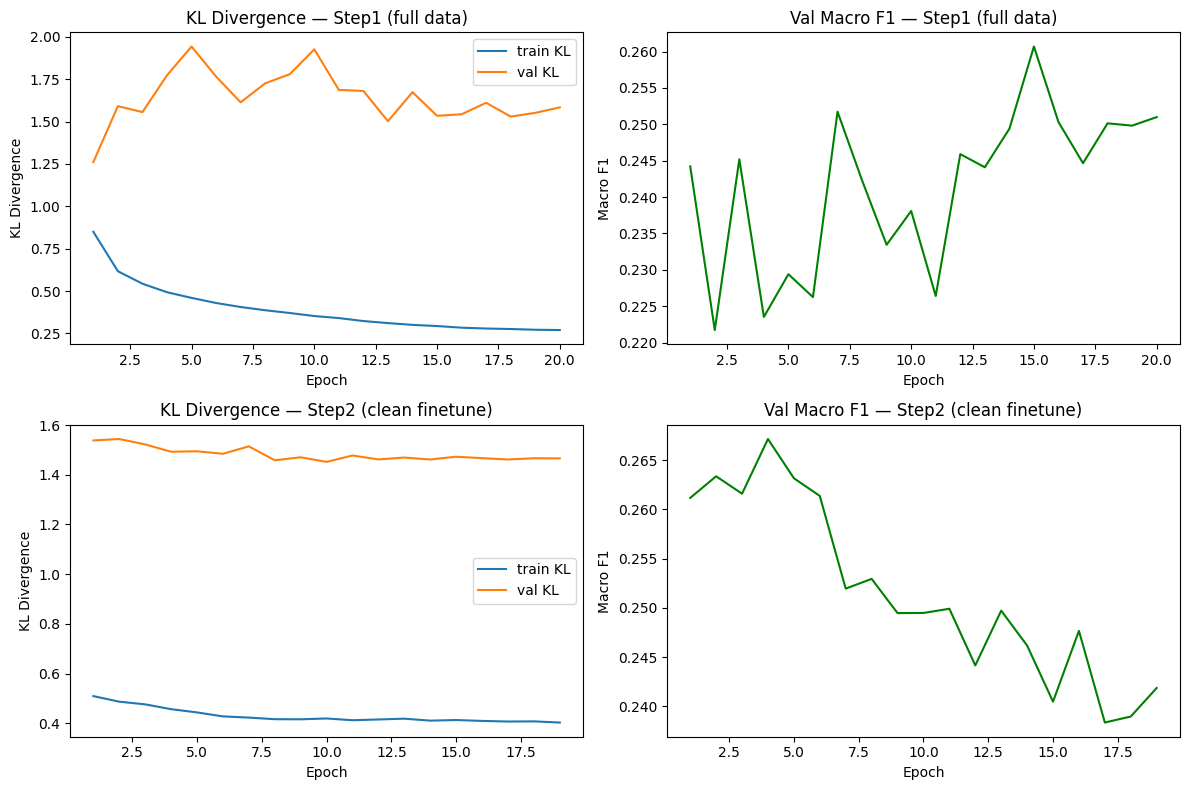

Step1 best macro_f1: 0.2607 (epoch 15)
Step2 best macro_f1: 0.2671 (epoch 4)


In [9]:
import matplotlib.pyplot as plt

# val CE panel dropped — shared_validate() reports KL and macro F1 only
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for row, (phase_key, phase_label) in enumerate([('step1', 'Step1 (full data)'), ('step2', 'Step2 (clean finetune)')]):
    hist = history[phase_key]
    if not hist:
        continue
    epochs_   = [h['epoch']    for h in hist]
    train_kl_ = [h['train_kl'] for h in hist]
    val_kl_   = [h['val_kl']   for h in hist]
    macro_f1_ = [h['macro_f1'] for h in hist]

    ax1, ax2 = axes[row]
    ax1.plot(epochs_, train_kl_, label='train KL')
    ax1.plot(epochs_, val_kl_,   label='val KL')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('KL Divergence')
    ax1.set_title(f'KL Divergence — {phase_label}'); ax1.legend()

    ax2.plot(epochs_, macro_f1_, color='green')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Macro F1')
    ax2.set_title(f'Val Macro F1 — {phase_label}')

plt.tight_layout()
plt.savefig('training_curves_v8.png', dpi=150)
plt.show()

for phase_key, phase_label in [('step1', 'Step1'), ('step2', 'Step2')]:
    hist = history[phase_key]
    if hist:
        f1s = [h['macro_f1'] for h in hist]
        print(f'{phase_label} best macro_f1: {max(f1s):.4f} (epoch {f1s.index(max(f1s))+1})')

In [10]:
# One-line summary per phase — copy into notebooks/RESULTS.md
for _key, _label in [('step1', 'cnn-1d-v8b-step2-lr-x10 (Step1 pretrain, full data — reused/retrained)'),
                     ('step2', 'cnn-1d-v8b-step2-lr-x10 (Step2 finetune, clean data, LR=1e-4)')]:
    _h = history[_key]
    if _h:
        print(f"{_label} | "
              f"val_kl={min(r['val_kl'] for r in _h):.4f} | "
              f"val_f1={max(r['macro_f1'] for r in _h):.4f}")

cnn-1d-v8-two-step (Step1 pretrain, full data) | val_kl=1.2616 | val_f1=0.2607
cnn-1d-v8-two-step (Step2 finetune, clean data) | val_kl=1.4516 | val_f1=0.2671
